# Métodos Tradicionales — Backtest 2017-2025

Implementa las **5 estrategias tradicionales** del Capítulo 5 de la tesina y las evalúa por año en NVDA, MSFT y GOOGL siguiendo el plan de metodología (§4 y §7):

| Estrategia | Sección tesina | Señal de compra | Señal de venta |
|---|---|---|---|
| Buy & Hold | 5.5.1 | Día 1 del periodo | Último día |
| SMA Crossover | 5.5.2 | SMA20 cruza arriba SMA50 | SMA20 cruza abajo SMA50 |
| RSI | 5.5.3 | RSI cruza arriba 30 | RSI cruza abajo 70 |
| MACD | 5.5.4 | MACD cruza arriba línea de señal | MACD cruza abajo línea de señal |
| Mean Reversion | 5.5.5 | Close ≤ banda inferior (BB) | Close ≥ banda superior (BB) |

**Reglas de backtest**: capital inicial \$10,000, costo de transacción 0.1%, sin *short selling*, posición 100% del capital cuando hay señal.

## 0. Imports y carga de datos

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

DATA_DIR = "datos"
TICKERS = ["NVDA", "MSFT", "GOOGL"]
AÑOS_TEST = list(range(2017, 2026))  # 2017..2025
COSTO = 0.001  # 0.1% por transaccion
CAPITAL_INICIAL = 10_000

datasets = {}
for tk in TICKERS:
    df = pd.read_csv(
        os.path.join(DATA_DIR, f"{tk}_dataset.csv"),
        parse_dates=["Date"], index_col="Date"
    ).sort_index()
    datasets[tk] = df
    print(f"{tk}: {df.shape[0]} filas | {df.index.min().date()} -> {df.index.max().date()}")

NVDA: 3721 filas | 2011-03-15 -> 2025-12-29
MSFT: 3721 filas | 2011-03-15 -> 2025-12-29
GOOGL: 3721 filas | 2011-03-15 -> 2025-12-29


## 1. Generadores de señales

Cada función devuelve una `pd.Series` de **posiciones** (0 o 1) por día. La posición del día *t* se decide con datos disponibles al cierre del día *t* y se mantendrá hasta que aparezca una nueva señal.

In [2]:
def signal_buy_and_hold(df: pd.DataFrame) -> pd.Series:
    """Posicion = 1 todos los dias (compra dia 1, vende ultimo dia)."""
    pos = pd.Series(1, index=df.index, dtype=int)
    pos.iloc[-1] = 0
    return pos


def signal_sma_crossover(df: pd.DataFrame) -> pd.Series:
    """Compra cuando SMA20 cruza arriba SMA50; venta cuando cruza abajo."""
    f, s = df["SMA_20"], df["SMA_50"]
    cross_up = (f > s) & (f.shift(1) <= s.shift(1))
    cross_down = (f < s) & (f.shift(1) >= s.shift(1))
    pos = pd.Series(np.nan, index=df.index)
    pos[cross_up] = 1
    pos[cross_down] = 0
    return pos.ffill().fillna(0).astype(int)


def signal_rsi(df: pd.DataFrame) -> pd.Series:
    """Compra cuando RSI<30 y luego cruza arriba 30; venta cuando RSI>70 y cruza abajo 70."""
    rsi = df["RSI_14"]
    cross_up_30 = (rsi > 30) & (rsi.shift(1) <= 30)
    cross_down_70 = (rsi < 70) & (rsi.shift(1) >= 70)
    pos = pd.Series(np.nan, index=df.index)
    pos[cross_up_30] = 1
    pos[cross_down_70] = 0
    return pos.ffill().fillna(0).astype(int)


def signal_macd(df: pd.DataFrame) -> pd.Series:
    """Compra cuando MACD cruza arriba la linea de senal; venta cuando cruza abajo."""
    macd, sig = df["MACD"], df["MACD_signal"]
    cross_up = (macd > sig) & (macd.shift(1) <= sig.shift(1))
    cross_down = (macd < sig) & (macd.shift(1) >= sig.shift(1))
    pos = pd.Series(np.nan, index=df.index)
    pos[cross_up] = 1
    pos[cross_down] = 0
    return pos.ffill().fillna(0).astype(int)


def signal_mean_reversion(df: pd.DataFrame) -> pd.Series:
    """Compra cuando Close toca/cae bajo la banda inferior; venta cuando alcanza la banda superior."""
    close = df["Close"]
    bb_l, bb_u = df["BB_lower"], df["BB_upper"]
    pos = pd.Series(np.nan, index=df.index)
    pos[close <= bb_l] = 1
    pos[close >= bb_u] = 0
    return pos.ffill().fillna(0).astype(int)


ESTRATEGIAS = {
    "Buy & Hold":     signal_buy_and_hold,
    "SMA Crossover":  signal_sma_crossover,
    "RSI":            signal_rsi,
    "MACD":           signal_macd,
    "Mean Reversion": signal_mean_reversion,
}
print("Generadores cargados:", list(ESTRATEGIAS.keys()))

Generadores cargados: ['Buy & Hold', 'SMA Crossover', 'RSI', 'MACD', 'Mean Reversion']


## 2. Engine de backtest

**Convención**: la posición del día *t* se decide al cierre con datos disponibles hasta *t* y se mantiene durante (*t*, *t+1*), ganando el retorno realizado de ese intervalo. Esto evita *look-ahead bias* (López de Prado, 2018).

$$r_{\text{strategy}}[t] = \text{pos}[t-1] \cdot r_{\text{real}}[t] - c \cdot |\Delta\text{pos}[t-1]|$$

In [3]:
def backtest(pos: pd.Series, ret: pd.Series, costo: float = COSTO) -> dict:
    """
    pos:  posicion del dia t (0 fuera, 1 comprado)
    ret:  retorno realizado del dia t = (Close[t]-Close[t-1])/Close[t-1]
    """
    pos = pos.astype(int)
    eff_pos = pos.shift(1).fillna(0)
    gross = eff_pos * ret

    delta = pos.diff().abs().fillna(0)
    tc = delta.shift(1).fillna(0) * costo

    strat_ret = (gross - tc).fillna(0)
    equity = (1 + strat_ret).cumprod()

    return {
        "strat_ret": strat_ret,
        "equity": equity,
        "delta_pos": delta,
        "eff_pos": eff_pos,
        "n_trades": int(delta.sum() / 2),
    }


def compute_metrics(strat_ret: pd.Series, equity: pd.Series, eff_pos: pd.Series, n_trades: int) -> dict:
    """Metricas financieras y de riesgo del backtest."""
    n = len(strat_ret)
    total_return = float(equity.iloc[-1] - 1) if n else np.nan
    annual_return = (1 + total_return) ** (252 / n) - 1 if n else np.nan

    sigma = strat_ret.std(ddof=1)
    vol_annual = float(sigma * np.sqrt(252))
    sharpe = float(strat_ret.mean() / sigma * np.sqrt(252)) if sigma > 0 else np.nan

    roll_max = equity.cummax()
    dd = (equity - roll_max) / roll_max
    max_dd = float(dd.min())

    pct_in_market = float(eff_pos.mean())
    dias_activos = (strat_ret != 0).sum()
    hit_ratio = float((strat_ret > 0).sum() / dias_activos) if dias_activos > 0 else np.nan

    return {
        "retorno_total":     total_return,
        "retorno_anual":     float(annual_return),
        "vol_anual":         vol_annual,
        "sharpe":            sharpe,
        "max_dd":            max_dd,
        "hit_ratio":         hit_ratio,
        "pct_en_mercado":    pct_in_market,
        "n_trades":          int(n_trades),
    }

## 3. Demostración: NVDA en 2024 (todas las estrategias)

Sanity check antes de loopear sobre las 81 combinaciones (3 acciones × 5 estrategias × 9 años + algunos *Buy & Hold* extra).

In [4]:
df_nvda = datasets["NVDA"]
df_2024 = df_nvda[df_nvda.index.year == 2024]
ret_2024 = df_2024["Close"].pct_change()

filas = []
for nombre, fn in ESTRATEGIAS.items():
    # Generar senal sobre todo el historial para no perder warmup
    pos_full = fn(df_nvda)
    # Cortar al periodo de evaluacion
    pos = pos_full.loc[df_2024.index]
    bt = backtest(pos, ret_2024, costo=COSTO)
    m = compute_metrics(bt["strat_ret"], bt["equity"], bt["eff_pos"], bt["n_trades"])
    filas.append({"estrategia": nombre, **m})

demo = pd.DataFrame(filas).set_index("estrategia")
demo

,retorno_total,retorno_anual,vol_anual,sharpe,max_dd,hit_ratio,pct_en_mercado,n_trades
estrategia,,,,,,,,
Buy & Hold,1.7887,1.7887,0.5241,2.2192,-0.2705,0.5578,0.9960,0
SMA Crossover,1.5361,1.5361,0.4653,2.2315,-0.2349,0.5427,0.7738,3
RSI,0.3317,0.3317,0.2512,1.2652,-0.1589,0.5357,0.2103,3
MACD,0.9181,0.9181,0.3367,2.1041,-0.2320,0.5417,0.5437,7
Mean Reversion,0.6731,0.6731,0.2818,1.9652,-0.1548,0.5714,0.1825,2


## 4. Evaluación completa: 3 acciones × 5 estrategias × 9 años

Las señales se generan sobre el historial completo (para que el *warm-up* de los indicadores no afecte) y luego se recortan al año de evaluación.

In [5]:
filas = []
equity_dict = {}  # (ticker, estrategia, anio) -> equity series

for tk in TICKERS:
    df = datasets[tk]
    ret_full = df["Close"].pct_change()
    señales_full = {nombre: fn(df) for nombre, fn in ESTRATEGIAS.items()}

    for año in AÑOS_TEST:
        idx_año = df.index.year == año
        if not idx_año.any():
            continue
        ret_año = ret_full[idx_año]
        for nombre, pos_full in señales_full.items():
            pos = pos_full[idx_año]
            bt = backtest(pos, ret_año, costo=COSTO)
            m = compute_metrics(bt["strat_ret"], bt["equity"], bt["eff_pos"], bt["n_trades"])
            filas.append({"ticker": tk, "estrategia": nombre, "año": año, **m})
            equity_dict[(tk, nombre, año)] = bt["equity"] * CAPITAL_INICIAL

tabla_maestra = pd.DataFrame(filas)
tabla_maestra.head(15)

,ticker,estrategia,año,retorno_total,retorno_anual,vol_anual,sharpe,max_dd,hit_ratio,pct_en_mercado,n_trades
0,NVDA,Buy & Hold,2017,0.9043,0.9092,0.4011,1.8110,-0.1974,0.5520,0.9960,0
1,NVDA,SMA Crossover,2017,0.5301,0.5327,0.3363,1.4392,-0.1791,0.5505,0.7809,1
2,NVDA,RSI,2017,0.1080,0.1084,0.1234,0.8961,-0.0646,0.5306,0.1873,2
3,NVDA,MACD,2017,0.3148,0.3162,0.3030,1.0530,-0.1312,0.4800,0.4582,10
4,NVDA,Mean Reversion,2017,0.6884,0.6920,0.2864,1.9748,-0.1275,0.5520,0.4861,3
5,NVDA,Buy & Hold,2018,-0.3285,-0.3295,0.4908,-0.5616,-0.5604,0.5040,0.9960,0
6,NVDA,SMA Crossover,2018,-0.1200,-0.1205,0.3019,-0.2733,-0.2497,0.4965,0.5578,3
7,NVDA,RSI,2018,-0.1036,-0.1040,0.3456,-0.1357,-0.4168,0.5304,0.4502,2
8,NVDA,MACD,2018,-0.3723,-0.3734,0.3187,-1.2976,-0.5019,0.4286,0.5378,12
9,NVDA,Mean Reversion,2018,-0.2473,-0.2482,0.4123,-0.4779,-0.4840,0.4880,0.4821,4


## 5. Tabla agregada por (ticker × estrategia)

Promedio sobre los 9 años para tener una visión consolidada.

In [6]:
agg = (
    tabla_maestra
    .groupby(["ticker", "estrategia"], sort=False)
    .agg(
        sharpe_medio=("sharpe", "mean"),
        sharpe_std=("sharpe", "std"),
        retorno_anual_medio=("retorno_anual", "mean"),
        max_dd_medio=("max_dd", "mean"),
        hit_ratio_medio=("hit_ratio", "mean"),
        pct_en_mercado=("pct_en_mercado", "mean"),
        trades_promedio=("n_trades", "mean"),
        años_sharpe_pos=("sharpe", lambda s: int((s > 0).sum())),
    )
)
agg

sharpe_medio  sharpe_std  retorno_anual_medio  \
ticker estrategia                                                      
NVDA   Buy & Hold            1.2843      1.2410               0.8743   
       SMA Crossover         0.8568      1.4855               0.5080   
       RSI                   1.0864      1.2132               0.3466   
       MACD                  0.8026      1.3084               0.3278   
       Mean Reversion        1.1987      1.0210               0.3821   
MSFT   Buy & Hold            1.2842      1.0443               0.3080   
       SMA Crossover         0.7379      1.4787               0.1608   
       RSI                   0.7961      0.8019               0.0925   
       MACD                  0.3218      1.0951               0.0333   
       Mean Reversion        1.0561      0.9209               0.1512   
GOOGL  Buy & Hold            1.0747      1.0386               0.3041   
       SMA Crossover         0.8338      1.1696               0.2099   
       RSI                   0.4423      0.7875               0.0451   
       MACD                  0.4652      0.9725               0.0969   
       Mean Reversion        0.9693      0.8656               0.1408   

                       max_dd_medio  hit_ratio_medio  pct_en_mercado  \
ticker estrategia                                                      
NVDA   Buy & Hold           -0.3477           0.5418          0.9960   
       SMA Crossover        -0.2791           0.5111          0.6779   
       RSI                  -0.1998           0.5547          0.3250   
       MACD                 -0.2780           0.4903          0.5216   
       Mean Reversion       -0.2522           0.5511          0.4002   
MSFT   Buy & Hold           -0.1706           0.5449          0.9960   
       SMA Crossover        -0.1632           0.5186          0.7168   
       RSI                  -0.1160           0.5531          0.3356   
       MACD                 -0.1502           0.4793          0.5051   
       Mean Reversion       -0.1240           0.5493          0.3906   
GOOGL  Buy & Hold           -0.2261           0.5409          0.9960   
       SMA Crossover        -0.1596           0.5193          0.6778   
       RSI                  -0.1442           0.5244          0.2999   
       MACD                 -0.1565           0.4805          0.5177   
       Mean Reversion       -0.1371           0.5506          0.3717   

                       trades_promedio  años_sharpe_pos  
ticker estrategia                                        
NVDA   Buy & Hold               0.0000                7  
       SMA Crossover            2.3333                7  
       RSI                      2.2222                8  
       MACD                     9.8889                6  
       Mean Reversion           2.6667                7  
MSFT   Buy & Hold               0.0000                8  
       SMA Crossover            2.3333                7  
       RSI                      2.1111                7  
       MACD                    10.5556                7  
       Mean Reversion           2.1111                8  
GOOGL  Buy & Hold               0.0000                8  
       SMA Crossover            2.2222                8  
       RSI                      1.6667                5  
       MACD                    10.5556                7  
       Mean Reversion           2.2222                8

In [7]:
# Ranking global: Sharpe medio agregando sobre las 3 acciones
ranking = (
    tabla_maestra
    .groupby("estrategia", sort=False)
    .agg(
        sharpe_medio=("sharpe", "mean"),
        retorno_anual_medio=("retorno_anual", "mean"),
        max_dd_medio=("max_dd", "mean"),
        años_sharpe_pos=("sharpe", lambda s: int((s > 0).sum())),
        n_observaciones=("sharpe", "size"),
    )
    .sort_values("sharpe_medio", ascending=False)
)
ranking

,sharpe_medio,retorno_anual_medio,max_dd_medio,años_sharpe_pos,n_observaciones
estrategia,,,,,
Buy & Hold,1.2144,0.4955,-0.2481,23,27
Mean Reversion,1.0747,0.2247,-0.1711,23,27
SMA Crossover,0.8095,0.2929,-0.2007,22,27
RSI,0.7750,0.1614,-0.1534,20,27
MACD,0.5299,0.1527,-0.1949,20,27


## 6. Tabla pivote — Sharpe por (estrategia, año) para cada acción

Permite ver fácilmente qué estrategia ganó en qué año y en qué acción.

In [8]:
for tk in TICKERS:
    print(f"\n=== Sharpe Ratio anual — {tk} ===")
    pivot = (
        tabla_maestra[tabla_maestra.ticker == tk]
        .pivot(index="estrategia", columns="año", values="sharpe")
        .reindex(list(ESTRATEGIAS.keys()))
    )
    display(pivot)


=== Sharpe Ratio anual — NVDA ===


año,2017,2018,2019,2020,2021,2022,2023,2024,2025
estrategia,,,,,,,,,
Buy & Hold,1.8110,-0.5616,1.5618,1.6351,2.0224,-0.8327,2.8242,2.2192,0.8794
SMA Crossover,1.4392,-0.2733,1.2877,1.1897,1.2542,-2.5892,2.2001,2.2315,0.9711
RSI,0.8961,-0.1357,0.4166,0.0866,3.1862,0.0198,2.8786,1.2652,1.1644
MACD,1.0530,-1.2976,1.4695,0.6654,2.2505,-0.7424,1.9952,2.1041,-0.2741
Mean Reversion,1.9748,-0.4779,1.0672,1.1726,2.0801,-0.2338,2.3739,1.9652,0.8663



=== Sharpe Ratio anual — MSFT ===


año,2017,2018,2019,2020,2021,2022,2023,2024,2025
estrategia,,,,,,,,,
Buy & Hold,2.3459,0.7950,2.4171,0.9829,2.2249,-0.7453,1.9739,0.7802,0.7837
SMA Crossover,2.3459,0.6099,2.2601,0.7203,1.3534,-2.6034,1.2756,-0.1208,0.8001
RSI,1.0644,-0.0088,0.6156,0.6423,2.0763,-0.1434,2.0035,0.7404,0.1749
MACD,0.9110,0.0892,0.3726,0.7244,2.0986,-1.8520,0.9780,0.0553,-0.4805
Mean Reversion,2.0601,0.7542,2.1490,0.8800,1.5415,-0.6916,1.7700,0.3114,0.7304



=== Sharpe Ratio anual — GOOGL ===


año,2017,2018,2019,2020,2021,2022,2023,2024,2025
estrategia,,,,,,,,,
Buy & Hold,1.8313,0.0456,1.1270,0.8338,2.2568,-1.0966,1.6461,1.2763,1.7517
SMA Crossover,1.4016,0.7481,1.2058,0.3743,1.8142,-1.7294,0.4771,0.7658,2.4468
RSI,0.8819,-0.3080,-0.3444,-0.0421,0.6112,-0.2494,2.0917,0.5696,0.7702
MACD,0.4402,-0.4114,0.7075,1.5467,0.4330,-1.6684,1.0369,1.0168,1.0853
Mean Reversion,1.3583,0.0793,2.2995,0.1423,1.7164,-0.2117,1.5199,0.5014,1.3185


## 7. Curvas de equity (todas las estrategias acumuladas 2017-2025)

Se concatenan los 9 años de equity multiplicando los retornos compuestos para visualizar el crecimiento total del capital invertido durante todo el horizonte.

<>:21: SyntaxWarning: invalid escape sequence '\$'
<>:21: SyntaxWarning: invalid escape sequence '\$'
C:\Users\hamga\AppData\Local\Temp\ipykernel_15836\2725981924.py:21: SyntaxWarning: invalid escape sequence '\$'
  ax.set_title(f"{tk} — equity 2017-2025 (capital inicial \${CAPITAL_INICIAL:,})")


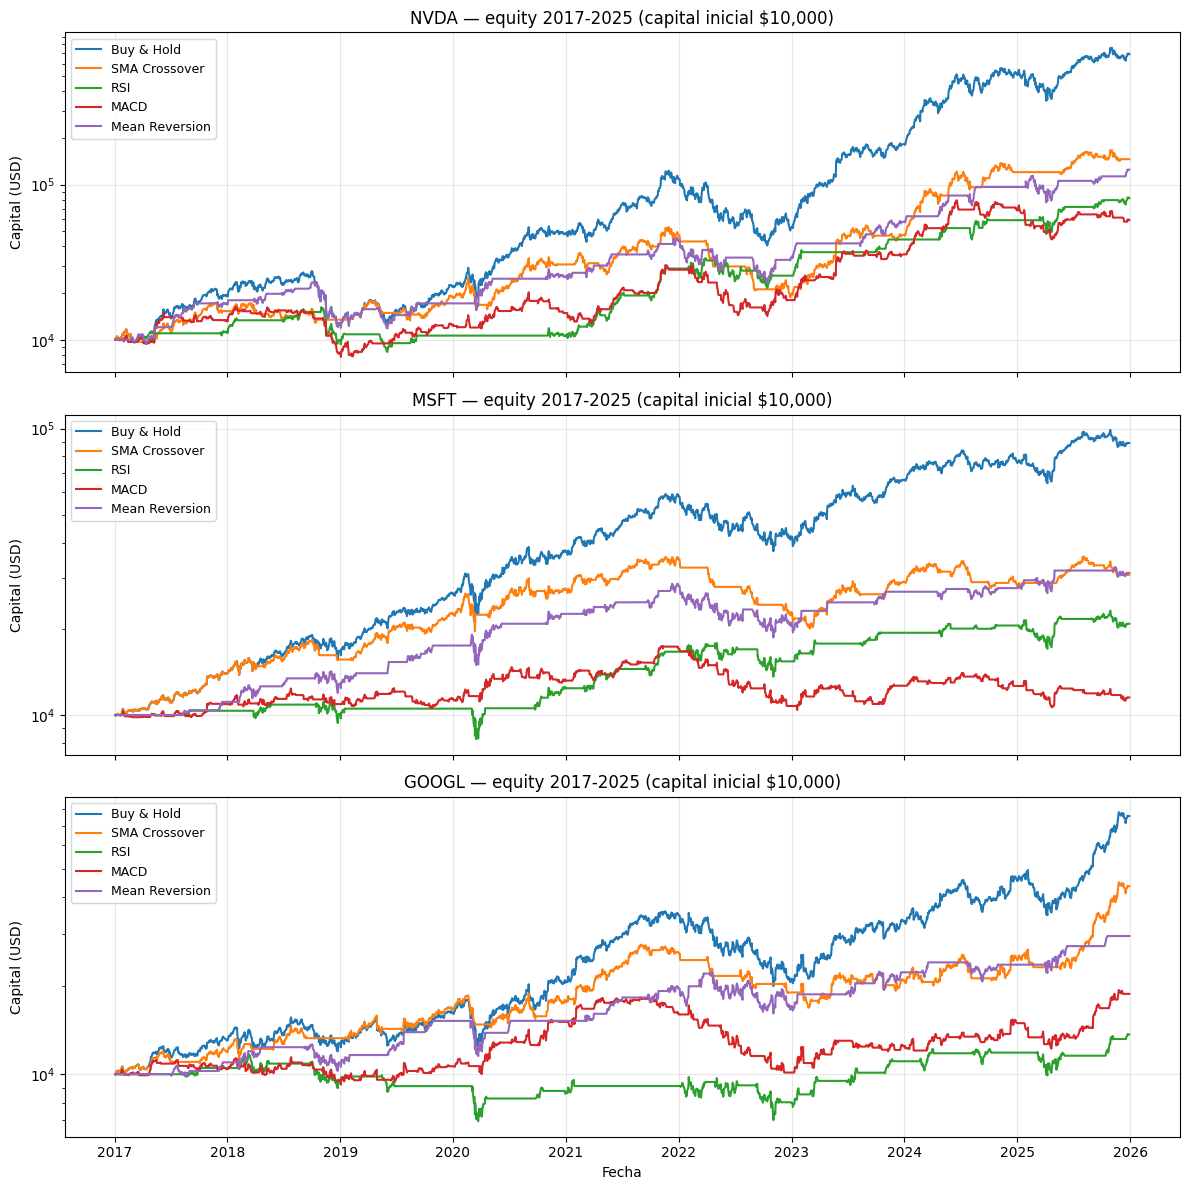

In [9]:
def equity_concatenada(ticker: str, estrategia: str) -> pd.Series:
    """Concatena los 9 años multiplicando los factores de crecimiento."""
    factor = 1.0
    pieces = []
    for año in AÑOS_TEST:
        eq = equity_dict.get((ticker, estrategia, año))
        if eq is None or eq.empty:
            continue
        crecimiento = eq / CAPITAL_INICIAL
        pieces.append(crecimiento * factor * CAPITAL_INICIAL)
        factor *= float(crecimiento.iloc[-1])
    return pd.concat(pieces) if pieces else pd.Series(dtype=float)


fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
for ax, tk in zip(axes, TICKERS):
    for nombre in ESTRATEGIAS:
        eq = equity_concatenada(tk, nombre)
        if not eq.empty:
            ax.plot(eq.index, eq.values, label=nombre, linewidth=1.5)
    ax.set_title(f"{tk} — equity 2017-2025 (capital inicial \${CAPITAL_INICIAL:,})")
    ax.set_ylabel("Capital (USD)")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left", fontsize=9)
axes[-1].set_xlabel("Fecha")
plt.tight_layout()
plt.show()

## 8. Resumen del régimen post-ChatGPT (2023-2025)

Sub-tabla específica del periodo del *boom* de IA generativa, que es el escenario que motiva la tesina.

In [10]:
post_chatgpt = tabla_maestra[tabla_maestra["año"].isin([2023, 2024, 2025])]
post_chatgpt_agg = (
    post_chatgpt
    .groupby(["ticker", "estrategia"], sort=False)
    .agg(
        sharpe_medio=("sharpe", "mean"),
        retorno_anual_medio=("retorno_anual", "mean"),
        max_dd_medio=("max_dd", "mean"),
    )
)
post_chatgpt_agg

sharpe_medio  retorno_anual_medio  max_dd_medio
ticker estrategia                                                     
NVDA   Buy & Hold            1.9743               1.5508       -0.2741
       SMA Crossover         1.8009               1.0630       -0.1935
       RSI                   1.7694               0.4813       -0.1476
       MACD                  1.2751               0.5889       -0.2494
       Mean Reversion        1.7351               0.5614       -0.2075
MSFT   Buy & Hold            1.1793               0.3032       -0.1634
       SMA Crossover         0.6517               0.1151       -0.1556
       RSI                   0.9729               0.1119       -0.0989
       MACD                  0.1843               0.0288       -0.1542
       Mean Reversion        0.9373               0.1502       -0.0895
GOOGL  Buy & Hold            1.5581               0.5412       -0.2307
       SMA Crossover         1.2299               0.3582       -0.1662
       RSI                   1.1438               0.2040       -0.1137
       MACD                  1.0463               0.2305       -0.1401
       Mean Reversion        1.1133               0.2087       -0.1163

## 9. Persistencia de resultados

Guarda la tabla maestra y las curvas de equity para que los notebooks de ML las puedan comparar después sin recalcular.

In [11]:
OUT_DIR = "resultados/tradicionales"
os.makedirs(OUT_DIR, exist_ok=True)

tabla_maestra.to_csv(os.path.join(OUT_DIR, "tabla_maestra.csv"), index=False)
agg.to_csv(os.path.join(OUT_DIR, "tabla_agregada.csv"))
ranking.to_csv(os.path.join(OUT_DIR, "ranking_global.csv"))

# Curvas de equity concatenadas (una columna por estrategia, una hoja por ticker)
for tk in TICKERS:
    eq_dict = {nombre: equity_concatenada(tk, nombre) for nombre in ESTRATEGIAS}
    eq_df = pd.DataFrame(eq_dict)
    eq_df.to_csv(os.path.join(OUT_DIR, f"equity_{tk}.csv"))

print(f"Resultados guardados en: {os.path.abspath(OUT_DIR)}")
print("Archivos:")
for f in sorted(os.listdir(OUT_DIR)):
    size_kb = os.path.getsize(os.path.join(OUT_DIR, f)) / 1024
    print(f"  {f}  ({size_kb:.1f} KB)")

Resultados guardados en: c:\Users\hamga\Documents\repo\ai-stock-price-prediction\resultados\tradicionales
Archivos:
  equity_GOOGL.csv  (248.3 KB)
  equity_MSFT.csv  (247.9 KB)
  equity_NVDA.csv  (249.6 KB)
  ranking_global.csv  (0.5 KB)
  tabla_agregada.csv  (2.3 KB)
  tabla_maestra.csv  (20.8 KB)
